# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

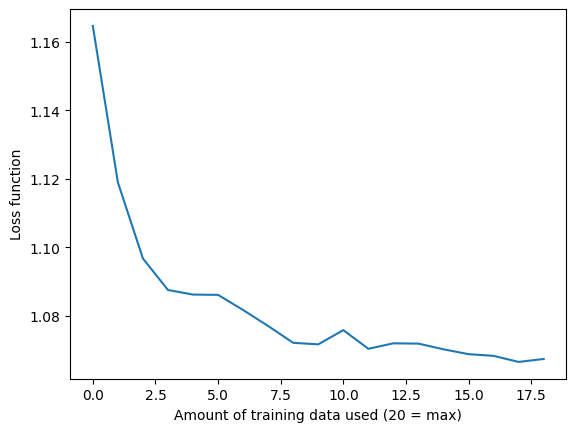

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

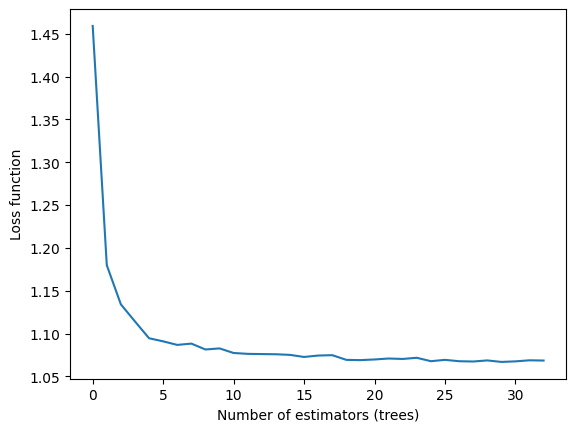

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

When looking at the two charts, I would choose to cut the Number of Estimators plot and keep the amount of training data plot. One reason is that the amount of training data plot isn't just a straight decrease and there are some fluctuations in the decrease. Furthermore, there is a slight increase at 10. These spikes and fluctuations make the graph more interesting to analyze and try to identify trends within the data. It also allows us to look into why there could be worse performance at certain amounts of training data.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

For my three datasets, I will be using a Random Forest Regressor model to perform predictions and will be using grid search cv to tune the hyperparameters. I want to use Grid Search CV instead since it does an exhaustive search for the best hyperparameter combination. What I will be testing for paramters are the max depth and the number of estimators used. I will also be using mean absolute error as my scoring mechanism.

## Dataset 1: Instacart Analysis

In [7]:
data1 = pd.read_csv('/workspaces/DX699---HW-Assignments/instacart.csv')

transform_cols = ['times_purchased', 'num_orders', 'frequency', 'Product Popularity', 'Last Product Order', 'Last Order', 'Orders Since Last Purchase']

for col in transform_cols:
    data1[f'log_{col}'] = np.log1p(data1[col])

data1_transformed = data1.drop(columns = ['times_purchased', 'num_orders', 'frequency', 'Product Popularity', 'Last Product Order', 'Last Order', 'Orders Since Last Purchase'])

data1_transformed.head()

,user_id,product_id,ordered,log_times_purchased,log_num_orders,log_frequency,log_Product Popularity,log_Last Product Order,log_Last Order,log_Orders Since Last Purchase
0,71,45,0.0,1.791759,3.178054,0.196710,0.005878,2.302585,3.178054,2.708050
1,71,117,1.0,2.995732,3.178054,0.602175,0.001219,3.178054,3.178054,0.000000
2,71,2078,0.0,0.693147,3.178054,0.042560,0.006478,1.386294,3.178054,3.044522
3,71,2825,0.0,1.098612,3.178054,0.083382,0.003743,1.945910,3.178054,2.890372
4,71,3376,1.0,1.098612,3.178054,0.083382,0.003602,2.995732,3.178054,1.609438


In [8]:
from sklearn.model_selection import train_test_split

X = data1_transformed.drop(columns = 'ordered')
y = data1_transformed['ordered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()

param_list = {'n_estimators' : [10, 33, 100], 'max_depth' : [3, 5, 7]}

gscv = GridSearchCV(rf_model, param_grid = param_list, scoring = 'neg_mean_absolute_error')

gscv.fit(X_train.values, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [10, 33, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [10]:
print(gscv.best_estimator_)
print(gscv.best_params_)
print(-gscv.best_score_)

RandomForestRegressor(max_depth=7, n_estimators=10)
{'max_depth': 7, 'n_estimators': 10}
0.10303867403477182


In [11]:
from sklearn.metrics import mean_absolute_error

best_model = RandomForestRegressor(n_estimators = 33, max_depth = 7, random_state = 42)

best_model.fit(X_train, y_train)

data1_preds = best_model.predict(X_test)

best_score = mean_absolute_error(y_test, data1_preds)

print(f'Best MAE Score: {best_score :.4f}')

Best MAE Score: 0.1047


In [12]:
feature_importances = best_model.feature_importances_
features = X.columns

importances = pd.DataFrame({'Features' : features, 'Importances' : feature_importances}).sort_values('Importances', ascending = False)

importances

,Features,Importances
4,log_frequency,0.577133
8,log_Orders Since Last Purchase,0.228637
2,log_times_purchased,0.084658
0,user_id,0.038921
5,log_Product Popularity,0.031634
1,product_id,0.016338
6,log_Last Product Order,0.013295
7,log_Last Order,0.005221
3,log_num_orders,0.004163


Looking at the MAE score, it means that on average, the predicted value is 0.1047 units away from the true unit. This mean the model does a pretty good job at predicting the correct outcome for the different samples. I am curious how the data will perform in a classifier model which I am looking to do in the future as the target is a binary classfier.

Furthermore, I am not surprised the most important feature for prediction is the log_frequency of purchases. If someone had only ordered something once or twice, I wouldn't think it would be reordered versus something that has been ordered a lot. However, it doesn't help when someone doesn't order a lot so their order history isn't as large which can lead to it getting incorrectly predicted since they just are not ordering a lot

## Dataset 2: Amazon Reviews

In [13]:
import ast
from sklearn.preprocessing import MultiLabelBinarizer

small_reviews = pd.read_csv('/workspaces/DX699---HW-Assignments/small_reviews[1].csv')

small_meta = pd.read_csv('/workspaces/DX699---HW-Assignments/small_meta[1].csv')

small_meta = small_meta.set_index(keys = 'parent_asin')

small_meta = small_meta.drop(columns = ['title', 'images'])

data2 = small_reviews.join(small_meta, on = 'parent_asin', how = 'inner')

data2 = data2.drop(columns = ['main_category', 'store', 'rating_number', 'videos', 'images', 'subtitle', 'author', 'bought_together', 'features', 'description', 'details', 'timestamp', 'text', 'title'])

data2['product_review_count'] = data2.groupby('asin').transform('size')
data2['user_review_count'] = data2.groupby('user_id').transform('size')

data2['price'] = data2['price'].fillna(data2['price'].median())

data2['categories'] = data2['categories'].apply(ast.literal_eval)

mlb = MultiLabelBinarizer()

categories = pd.DataFrame(mlb.fit_transform(data2['categories']), columns = mlb.classes_, index = data2.index)

top_30 = categories.sum().sort_values(ascending = False).head(31).index

categories = categories[top_30[1:31]]

data2 = data2.drop(columns = 'categories')

data2 = data2.join(categories)

columns_to_transform = ['helpful_vote', 'average_rating', 'price', 'product_review_count', 'user_review_count']

for col in columns_to_transform:
    data2[f'log_{col}'] = np.log1p(data2[col])

data2_transformed = data2.drop(columns = ['helpful_vote', 'average_rating', 'price', 'product_review_count', 'user_review_count'])

data2_transformed = data2_transformed.reset_index(drop = True)

for i in range(len(data2_transformed)):
    if data2_transformed.iloc[i]['rating'] == 4:
        data2_transformed.loc[i, 'liked'] = 1
    elif data2_transformed.iloc[i]['rating'] == 5:
        data2_transformed.loc[i, 'liked'] = 1
    else:
        data2_transformed.loc[i, 'liked'] = 0

X = data2_transformed.drop(columns = ['asin', 'parent_asin', 'user_id', 'liked'])
y = data2_transformed['liked']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

param_list = {'n_estimators' : [10, 33, 100], 'max_depth' : [3, 12, 25]}

rf_model = RandomForestRegressor()

gscv = GridSearchCV(rf_model, param_grid = param_list, scoring = 'neg_mean_absolute_error')

gscv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 12, ...], 'n_estimators': [10, 33, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [15]:
print(gscv.best_estimator_)
print(gscv.best_params_)
print(gscv.best_score_)

RandomForestRegressor(max_depth=3, n_estimators=10)
{'max_depth': 3, 'n_estimators': 10}
0.0


In [16]:
best_model = RandomForestRegressor(n_estimators= 10, max_depth = 3)

best_model.fit(X_train, y_train)

data2_preds = best_model.predict(X_test)

best_score = mean_absolute_error(y_test, data2_preds)

print(f'Best MAE Score: {best_score :.4f}')

Best MAE Score: 0.0000


In [17]:
feature_importances = best_model.feature_importances_
features = X.columns

importances = pd.DataFrame({'Features' : features, 'Importances' : feature_importances}).sort_values('Importances', ascending = False)

importances

,Features,Importances
0,rating,1.0
1,verified_purchase,0.0
2,Beverages,0.0
3,Snacks & Sweets,0.0
4,Pantry Staples,0.0
5,Coffee,0.0
6,Snack Foods,0.0
7,Candy & Chocolate,0.0
8,"Bottled Beverages, Water & Drink Mixes",0.0
9,Cooking & Baking,0.0


In [18]:
# Trying without ratings column

X = X.drop(columns = 'rating')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

gscv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 12, ...], 'n_estimators': [10, 33, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [19]:
print(gscv.best_estimator_)
print(gscv.best_params_)
print(-gscv.best_score_)

RandomForestRegressor(max_depth=3, n_estimators=10)
{'max_depth': 3, 'n_estimators': 10}
0.21705085602797053


In [20]:
best_model = RandomForestRegressor(n_estimators= 10, max_depth = 3, random_state = 42)

best_model.fit(X_train, y_train)

data2_preds = best_model.predict(X_test)

best_score = mean_absolute_error(y_test, data2_preds)

print(f'Best MAE Score: {best_score :.4f}')

Best MAE Score: 0.2441


In [21]:
feature_importances = best_model.feature_importances_
features = X.columns

importances = pd.DataFrame({'Features' : features, 'Importances' : feature_importances}).sort_values('Importances', ascending = False)

importances

,Features,Importances
32,log_average_rating,0.327258
33,log_price,0.297815
31,log_helpful_vote,0.151697
27,"Canned, Jarred & Packaged Foods",0.070590
35,log_user_review_count,0.070210
6,Candy & Chocolate,0.029285
34,log_product_review_count,0.019179
8,Cooking & Baking,0.010962
14,"Soups, Stocks & Broths",0.009718
15,Nuts & Seeds,0.008333


Looking at the MAE score for the data with the ratings column, the model is able to perfectly predict whether someone liked the item or not, no matter if it is training or testing data. I proceeded to remove the rating column to see if that was affecting how the model is performing, which it seems to be. The best score for the model without the ratings column was 0.2441 which means that the predictions on average are 0.2441 off. I would be curious to see how it performs in a classfication model with and without the ratings column and which model would be preferred in the industry. 


Furthermore, I am surprised that the model only used the ratings column for prediction and think it would be best to remove it in future analysis since it makes the rest of the features unused. In the future, I think the dataset without the ratings column may not perform as well but will not be overfitted and biased towards the rating.

## Dataset 3: Ecommerce Data

In [22]:
data3 = pd.read_csv('/workspaces/DX699---HW-Assignments/data.csv', encoding = 'windows-1252')
data3['Purchased'] = 1

customer_id = data3['Customer ID'].values
segments = data3['Segment'].values
cities = data3['City'].values
state = data3['State'].values
region = data3['Region'].values
product_id = data3['Product ID'].values
categories = data3['Category'].values
subcategories = data3['Sub-Category'].values

def generate_row(df):
    row = {}

    row['Customer ID'] = np.random.choice(customer_id)
    cust_id = row['Customer ID']
    purchased = set(df[df['Customer ID'] == cust_id]['Product ID'])
    candidates = list(set(product_id) - purchased)

    row['Segment'] = np.random.choice(segments)
    row['State'] = np.random.choice(state)
    row['City'] = np.random.choice(cities)
    row['Region'] = np.random.choice(region)
    row['Product ID'] = np.random.choice(candidates)
    row['Category'] = np.random.choice(categories)
    row['Sub-Category'] = np.random.choice(subcategories)

    row['Sales'] = 0
    row['Discount'] = 0
    row['Quantity'] = 0
    row['Profit'] = 0
    row['Purchased'] = 0

    return row

fake_rows = pd.DataFrame([generate_row(data3) for n in range(1000)])

fake_df = pd.concat([data3, fake_rows], ignore_index = True)

fake_df = fake_df.drop(columns = ['Row ID', 'Product Name', 'Country', 'Postal Code', 'Order ID', 'Order Date'])

fake_df_encoded = pd.get_dummies(fake_df, columns = ['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category'], dtype = int)

X = fake_df_encoded.drop(columns = ['Customer ID', 'Product ID', 'City', 'Purchased'])
y = fake_df_encoded['Purchased']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

param_list = {'n_estimators' : [10, 33, 100], 'max_depth' : [5, 15, 30]}

rf_model = RandomForestRegressor()

gscv = GridSearchCV(rf_model, param_grid = param_list, scoring = 'neg_mean_absolute_error')

gscv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 15, ...], 'n_estimators': [10, 33, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [24]:
print(gscv.best_estimator_)
print(gscv.best_params_)
print(gscv.best_score_)

RandomForestRegressor(max_depth=5, n_estimators=33)
{'max_depth': 5, 'n_estimators': 33}
-4.391743522178304e-05


In [25]:
best_model = RandomForestRegressor(n_estimators = 33, max_depth = 5)

best_model.fit(X_train, y_train)

data3_preds = best_model.predict(X_test)

best_score = mean_absolute_error(y_test, data3_preds)

print(f'Best MAE Score: {best_score :.4f}')

Best MAE Score: 0.0000


In [26]:
feature_importances = best_model.feature_importances_
features = X.columns

importances = pd.DataFrame({'Features' : features, 'Importances' : feature_importances}).sort_values('Importances', ascending = False)

importances

,Features,Importances
0,Sales,0.69697
1,Quantity,0.30303
2,Discount,0.00000
3,Profit,0.00000
4,Ship Mode_First Class,0.00000
...,...,...
77,Sub-Category_Paper,0.00000
78,Sub-Category_Phones,0.00000
79,Sub-Category_Storage,0.00000
80,Sub-Category_Supplies,0.00000


Once again this dataset is in a similar situation as Dataset 2 where the models are producing a perfect MAE score for both the training and test data. This could mean that the models are overfitting and/or have features that are specific to whether or not something is ordered. I believe that the fake rows are making it very easy for the model to predict whether are not someone is ordering it since all of the numerical float entries are set to 0 since they didn't actually purchase anything. It is concerning that the model is also overfitted, so I will need to look into ways to maybe make the fake rows seem more realistic.

Furthermore, I am not surprised the quantity and sales are the only two features used to predict whether or not an item is ordered. Those are the items that have 0 in them which only means someone didn't order the item.

In [33]:
display(fake_df_encoded['Purchased'].value_counts())
display(data2_transformed['liked'].value_counts())
display(data1_transformed['ordered'].value_counts())

Purchased
1    3312
0    1000
Name: count, dtype: int64

liked
1.0    502
0.0     81
Name: count, dtype: int64

ordered
0.0    302447
1.0     19992
Name: count, dtype: int64

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

There are no charts in this span of pages, so I am recreating a chart on page 

In [28]:
data = {'Education' : [24, 14, 7], 'Agriculture & Rural Development' : [17, 12, 8], 'Poverty Reduction' : [15, 10, 7], 
        'Reconstruction' : [9, 5, 4], 'Economic Growth' : [7, 5, 5], 'Health' : [3, 7, 6], 
        'Job Creation' : [4, 6, 5],'Governance' : [5, 5, 4], 'Anti-corruption' : [4, 4, 6], 
        'Transport' : [4, 4, 4], 'Energy' : [3, 4, 4], 'Law & Justice' : [2, 3, 4], 
        'Basic Infrastructure' : [2, 3, 3], 'Public Sector Reform' : [2, 3, 3],
        'Public Financial Management' : [1, 3, 3]}

df = pd.DataFrame(data, index = ['Most Important', '2nd Most Important', '3rd Most Important'])

df.head()

,Education,Agriculture & Rural Development,Poverty Reduction,Reconstruction,Economic Growth,Health,Job Creation,Governance,Anti-corruption,Transport,Energy,Law & Justice,Basic Infrastructure,Public Sector Reform,Public Financial Management
Most Important,24,17,15,9,7,3,4,5,4,4,3,2,2,2,1
2nd Most Important,14,12,10,5,5,7,6,5,4,4,4,3,3,3,3
3rd Most Important,7,8,7,4,5,6,5,4,6,4,4,4,3,3,3


Text(0.0, 1.0, 'Top 15 Development Priorities, According to Survey')

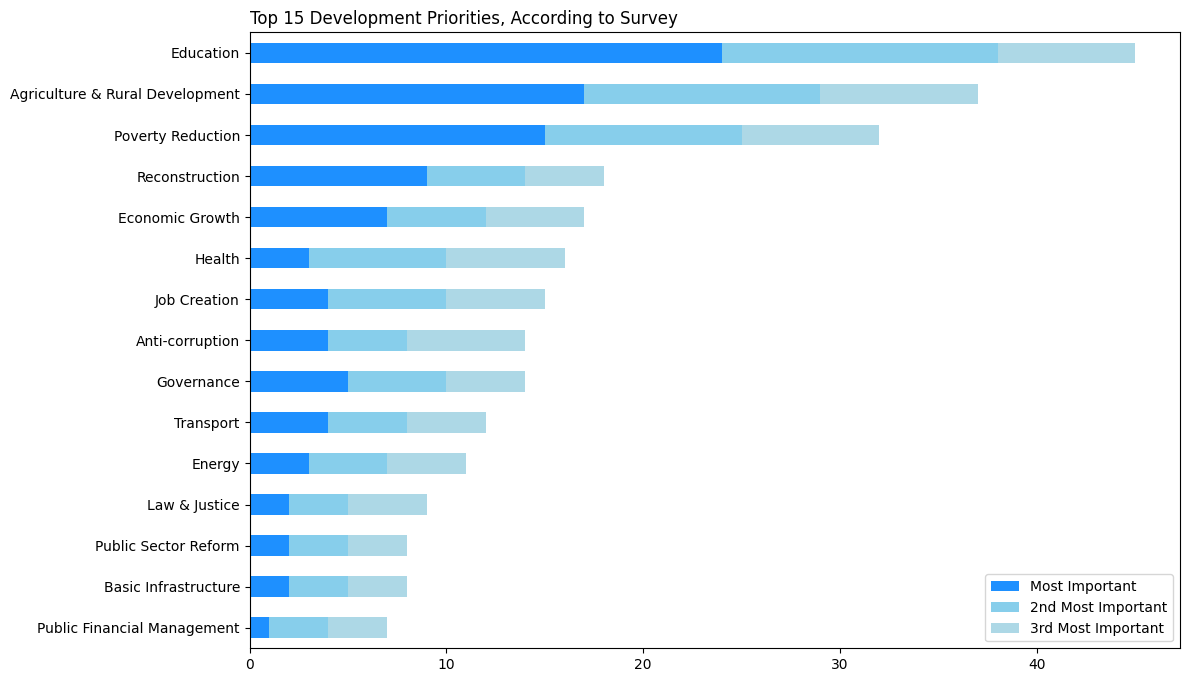

In [29]:
df_transposed = df.T

df_transposed['Total'] = df_transposed.sum(axis=1)

df_sorted = df_transposed.sort_values(by='Total', ascending=True)

df_sorted = df_sorted.drop(columns=['Total'])

df_sorted.plot(kind = 'barh', stacked = True, figsize = (12, 8), color = ['dodgerblue', 'skyblue', 'lightblue'])

plt.title('Top 15 Development Priorities, According to Survey', loc = 'left')